## **Read data and Imports**

In [1]:
import pandas as pd
import tensorflow as tf
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skrebate import ReliefF
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os
import random
import cv2 as cv2
import sklearn
from sklearn.feature_selection import (
    mutual_info_regression,  # Information Gain
    chi2,                    # Chi-square Test
    f_classif,               # ANOVA (F-test)
    SelectKBest,             # Select top k features
    VarianceThreshold        # Variance Threshold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

2026-04-20 20:43:49.620167: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 20:43:49.620257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 20:43:49.675861: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 20:43:49.788853: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 20:43:51.282899: W tensorflow/compiler/tf2

In [2]:
data = pd.read_csv("../../Data/dataset_split/train/train.csv")

## **Preprocessing**

**Feature Engineering**

In [27]:
data2 = data.copy()
# data2.drop(columns=['image_id','patient_id'],inplace = True)

In [ ]:
data2.drop(columns=['nationality'],inplace=True)
data2.drop(columns=['insuline'],inplace=True)
data2.drop(columns=['focus', 'Illuminaton', 'image_field', 'artifacts'],inplace=True)
data2.drop(columns=['diabetes_time_y','comorbidities'],inplace=True)
data2.drop(columns=['camera'],inplace=True)
data2.drop(columns=['quality'],inplace=True)
data2.drop(columns=['other'],inplace=True)
# high correlated with X feature
data2.drop(columns=['DR_SDRG'],inplace=True)

In [29]:
data2['exam_eye'] = data2['exam_eye'].map({1: 0, 2: 1})

data2['vessels'] = data2['vessels'].map({1: 0, 2: 1})

data2['macula'] = data2['macula'].map({1: 0, 2: 1})

data2['patient_sex'] = data2['patient_sex'].map({1: 0, 2: 1})

data2['diabetes'] = data2['diabetes'].map({'yes': 1, 'No': 0})

data2['optic_disc'] = data2['optic_disc'].map({1: 0, 2: 1})

In [30]:
count = 1
for col in data2.columns:
    print(f"{count}. Unique Values for [ {col} ] is : ",data2[col].unique(),'\n')
    count+=1

1. Unique Values for [ image_id ] is :  ['img00001' 'img00002' 'img00003' ... 'img16262' 'img16265' 'img16266'] 

2. Unique Values for [ patient_id ] is :  [   1    2    3 ... 8520 8522 8524] 

3. Unique Values for [ patient_age ] is :  [48. 18. 22. 23. 14. 20. 28. 37. 21. 16. 24. 26. 19. 17. 13. 27. 39. 25.
 30. 15. 29. 57. 44. 38. 47. 42. 10. 59. 32. 66. 82. 87. 80. 41. 76. 71.
 73. 83. 45. 61. 55. 75. 81. 72. 64. 46. 74. 65. 31. 33. 53. 50. 51. 49.
 63. 62. 52. 70. 79. 60. 78. 54. 56. 77. 58. 85. 86. 84. 69. 11. 68. nan
  9. 91. 36. 90. 67. 88.  7. 35. 40. 43. 89. 34. 12.  8. 95. 97.  6. 93.
 94.  5. 92.] 

4. Unique Values for [ patient_sex ] is :  [0 1] 

5. Unique Values for [ exam_eye ] is :  [0 1] 

6. Unique Values for [ diabetes ] is :  [1 0] 

7. Unique Values for [ optic_disc ] is :  [0 1] 

8. Unique Values for [ vessels ] is :  [0 1] 

9. Unique Values for [ macula ] is :  [0 1] 

10. Unique Values for [ DR_ICDR ] is :  [0 1 2 4 3] 

11. Unique Values for [ diabetic_retin

In [31]:
def show_missing(data2):
    """
    Visualizes and reports missing values in a Pandas data2Frame.

    Parameters:
    - data2 (data2Frame): The input Pandas data2Frame to check for missing values.

    Returns:
    None

    This function performs the following tasks:
    1. Displays a missing data2 matrix plot to visualize the location of missing values in the data2Frame.
    2. Prints the percentage of missing values in each column with missing data2.
    3. Creates a bar plot to visualize the percentage of missing values in each column.

    Example usage:
    show_missing(data2)
    """
    
    # Visualize the percentage of missing data2 using a bar plot
    msno.matrix(data2)
    
    
    # Print the percentage of missing values in the columns with missing
    features_with_nan = [features for features in data2.columns if data2[features].isnull().sum()>=1]
    print(f'{len(features_with_nan)} columns with missing values detected:')

    for features in features_with_nan:
        print(features , np.round(data2[features].isnull().mean(),4) * 100 , '% missing values')

    
    # Create a bar plot to visualize missing values
    # Calculate the percentage of missing data2 in each column
    missing_percentage = data2.isnull().mean() * 100
    missing_percentage
    
    plt.figure(figsize=(10, 6))
    missing_percentage.plot(kind='bar', color='skyblue')
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    plt.show()

In [32]:
data2['patient_age_missing'] = data2['patient_age'].isnull().astype(int)
data2['patient_age'] = data2['patient_age'].fillna(data2['patient_age'].median())

0 columns with missing values detected:


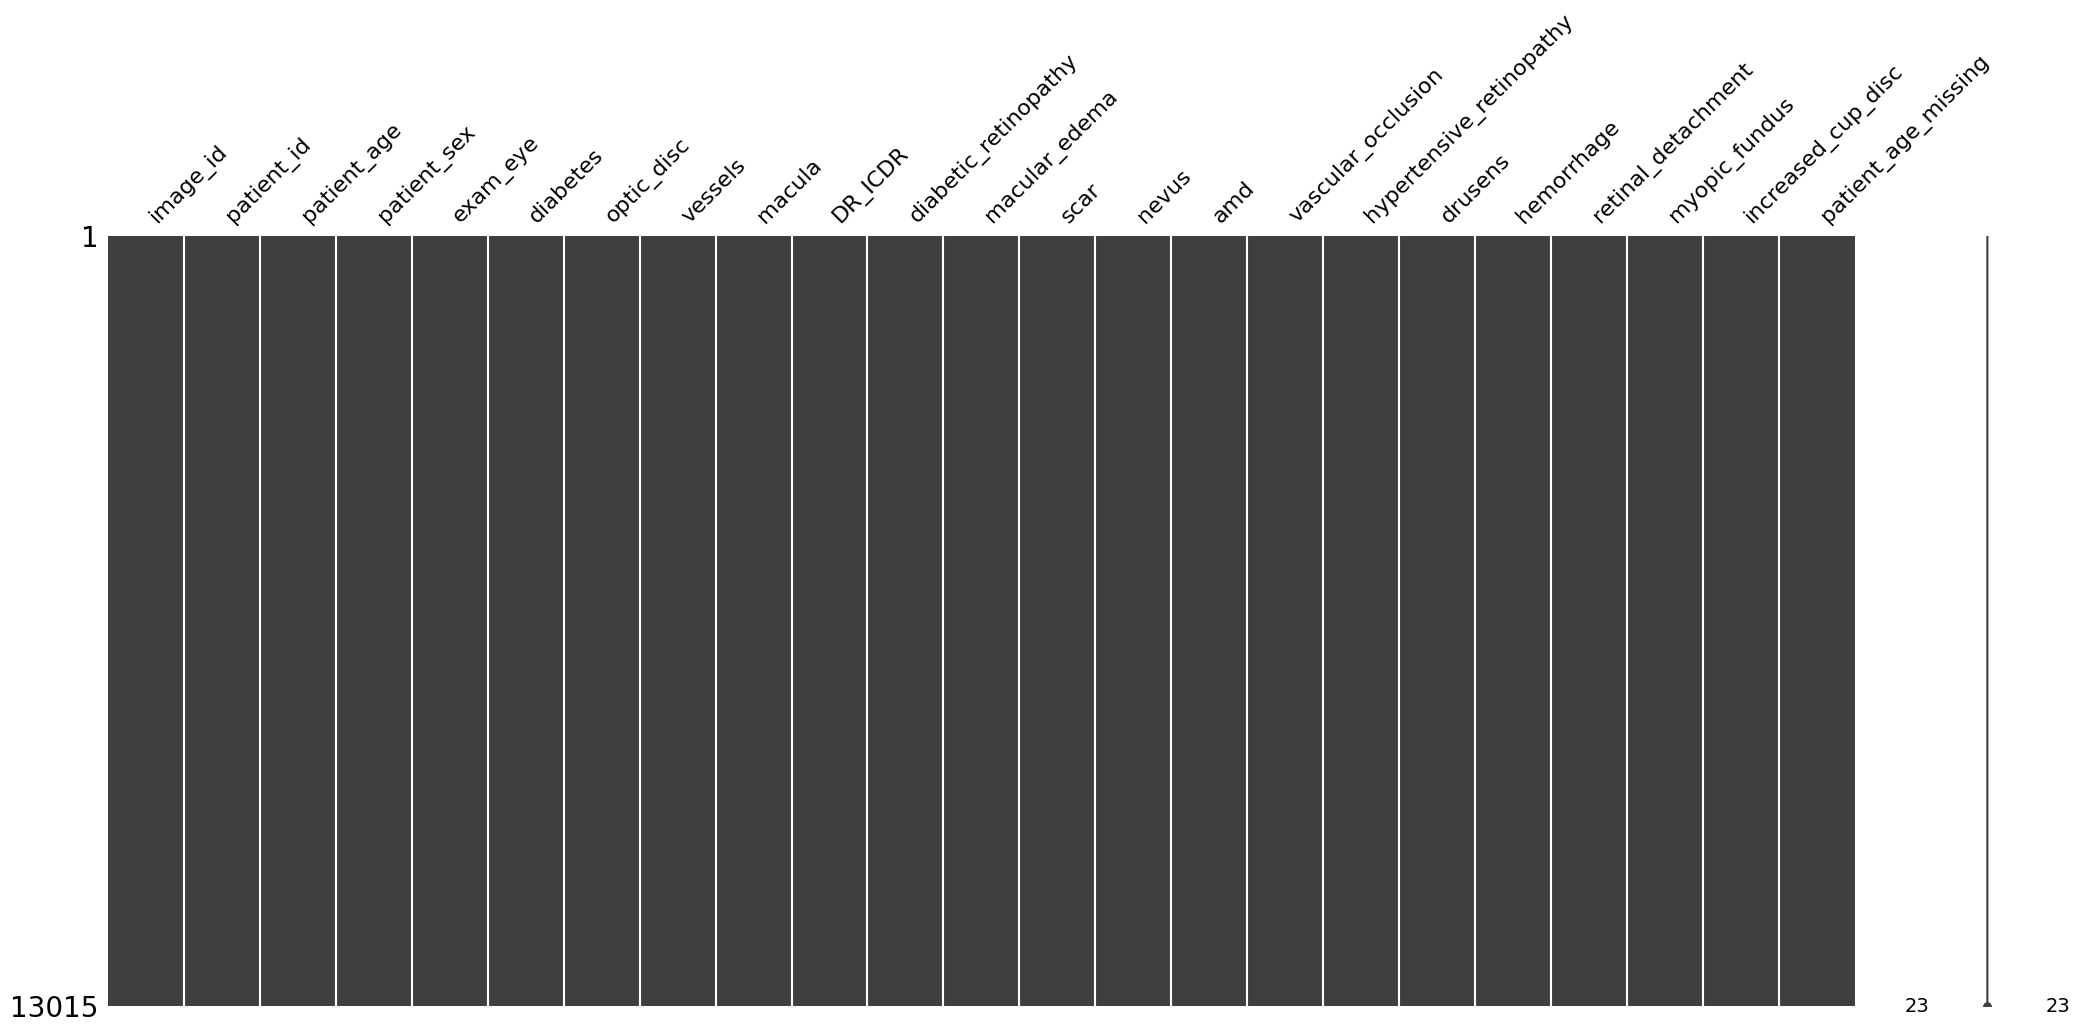

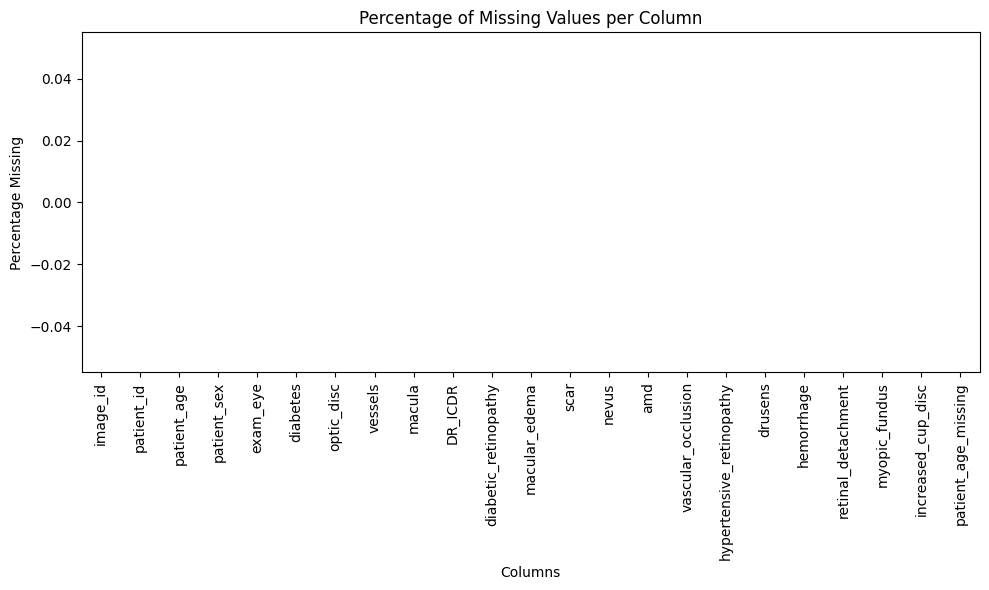

In [33]:
show_missing(data2)

In [54]:
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
# data2_clean.drop(columns=['DR_ICDR'],inplace=True)

## **Feature Selection techniques**

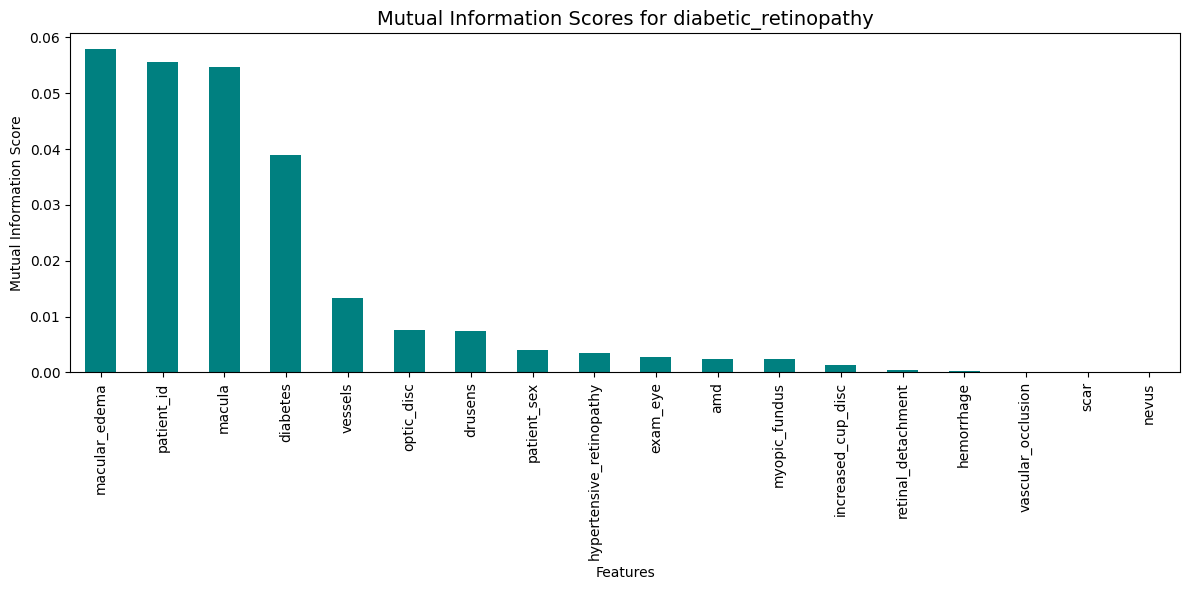

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# 1. Prepare data2
# Ensure we only use numeric data2 and define our single target
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'

# 2. Separate Features and Target
y = data2_clean[target]
X = data2_clean.drop(columns=[target, 'patient_age'], errors='ignore')

# 3. Compute Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# 4. Convert to Series and Sort
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# 5. Initialize a single plot
fig, ax = plt.subplots(figsize=(12, 6))

# 6. Plot
mi_series.plot(kind="bar", color="teal", ax=ax)

# 7. Customizing the plot
ax.set_title(f"Mutual Information Scores for {target}", fontsize=14)
ax.set_ylabel("Mutual Information Score")
ax.set_xlabel("Features")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
import pandas as pd

target = 'diabetic_retinopathy'

# 1. Start from full data2frame
data2 = data2.copy()

# 2. Separate target
y = data2[target]

# 3. Drop target from features
X = data2.drop(columns=[target], errors='ignore')

# 4. Keep only categorical/binary columns
#    This keeps:
#    - object/category columns
#    - integer columns with small number of unique values (binary / categorical)
categorical_cols = []

for col in X.columns:
    if X[col].dtype == 'object' or str(X[col].dtype) == 'category':
        categorical_cols.append(col)
    elif pd.api.types.is_integer_dtype(X[col]) and X[col].nunique() <= 10:
        categorical_cols.append(col)

X_cat = X[categorical_cols].copy()

# 5. One-hot encode object/category columns
X_cat = pd.get_dummies(X_cat, drop_first=False)

# 6. Fill missing values if needed
X_cat = X_cat.fillna(0)

# 7. Chi-square
chi_scores, p_values = chi2(X_cat, y)

# 8. Create result table
chi_data2 = pd.data2Frame({
    'Feature': X_cat.columns,
    'Chi2 Score': chi_scores,
    'p-value': p_values
}).sort_values(by='Chi2 Score', ascending=False)

# 9. Show results
print(chi_data2)

# 10. Plot top features
top_n = 20
plt.figure(figsize=(12, 6))
plt.bar(chi_data2['Feature'].head(top_n), chi_data2['Chi2 Score'].head(top_n))
plt.title(f'Chi-Square Feature Importance for {target} (Categorical Features Only)')
plt.ylabel('Chi-square Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

AttributeError: module 'pandas' has no attribute 'data2Frame'

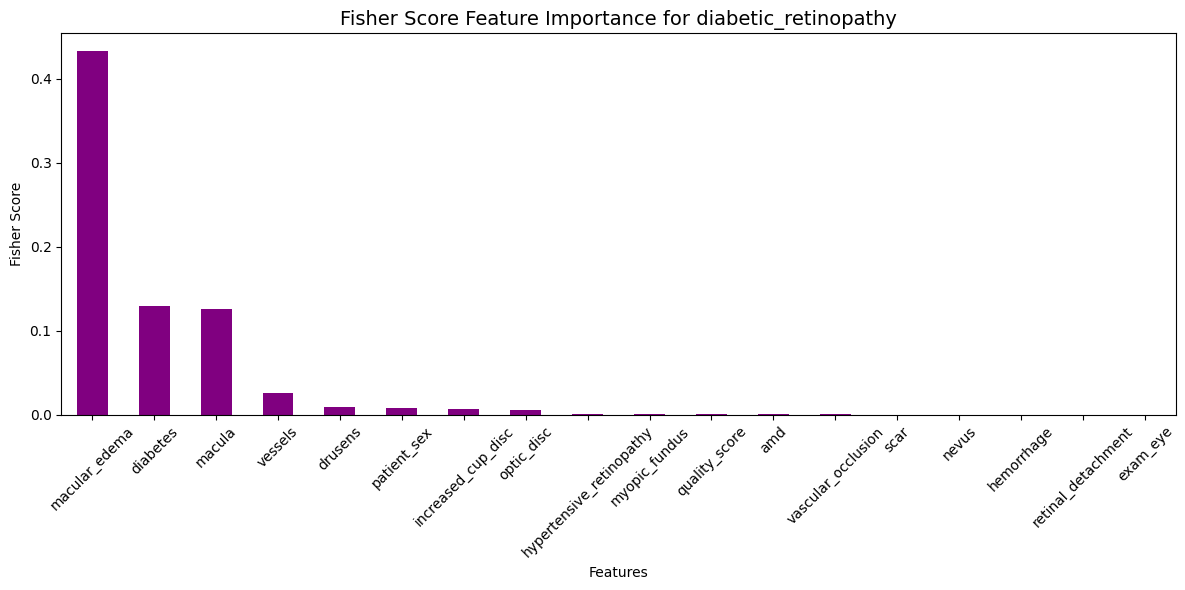

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def fisher_score(X, y, eps=1e-10):
    classes = np.unique(y)
    overall_mean = np.mean(X, axis=0)

    between_var = np.zeros(X.shape[1])
    within_var = np.zeros(X.shape[1])

    for c in classes:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        n_c = X_c.shape[0]

        between_var += n_c * (mean_c - overall_mean) ** 2
        within_var += np.sum((X_c - mean_c) ** 2, axis=0)

    return between_var / (within_var + eps)

# 2. Prepare base data2
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'

# 3. Separate Features and Target
y = data2_clean[target]
# Dropping target, patient_age, and patient_id to keep features clean
X = data2_clean.drop(columns=[target, 'patient_age', 'patient_id'], errors='ignore')

# 4. Compute Fisher Score
# Converting to numpy as required by your function
fisher_scores = fisher_score(X.to_numpy(), y.to_numpy())

# 5. Convert to Series and Sort
fisher_series = pd.Series(fisher_scores, index=X.columns).sort_values(ascending=False)

# 6. Initialize the plot
plt.figure(figsize=(12, 6))

# 7. Plot
fisher_series.plot(kind='bar', color='purple')

# 8. Customizing the plot
plt.title(f"Fisher Score Feature Importance for {target}", fontsize=14)
plt.ylabel("Fisher Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

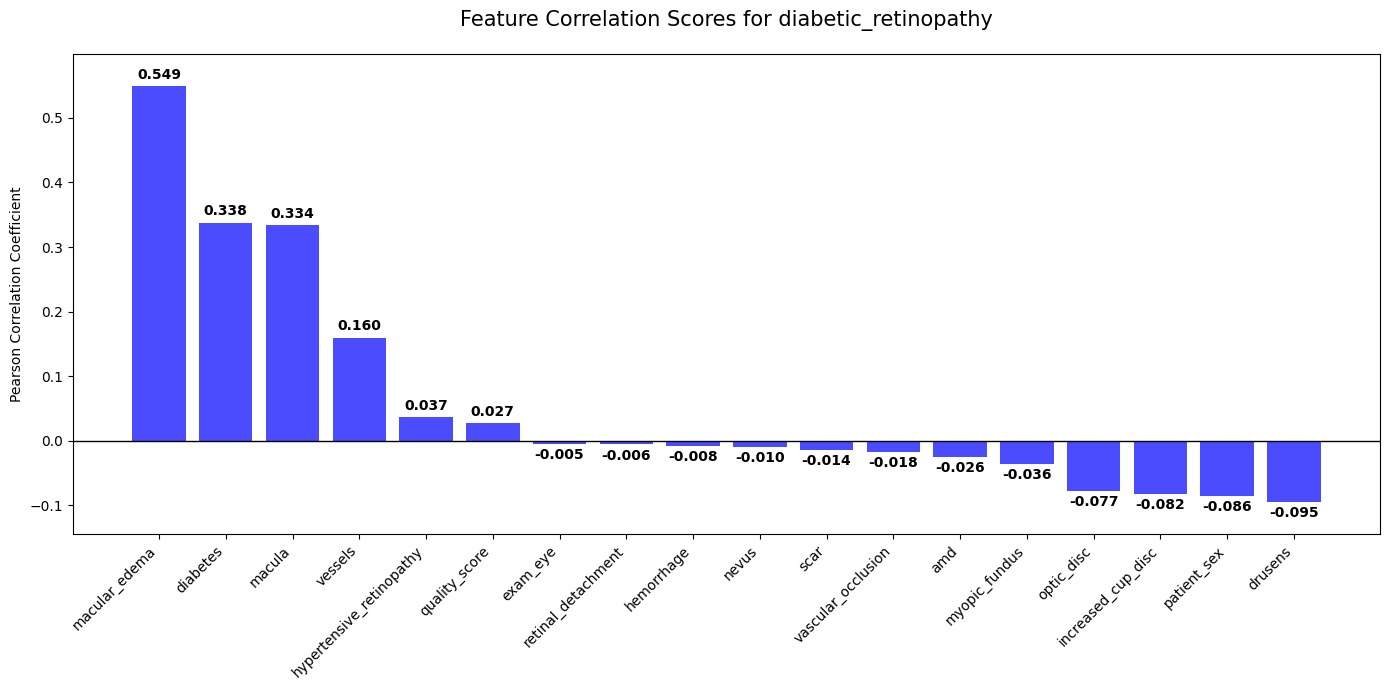

In [ ]:

data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'
y = data2_clean[target]
X = data2_clean.drop(columns=[target, 'patient_age', 'patient_id'], errors='ignore')

# 2. Compute and Sort Scores
corr_scores = X.apply(lambda col: col.corr(y)).sort_values(ascending=False)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(corr_scores.index, corr_scores.values, color="blue", alpha=0.7)

# 4. Add the numbers above (or below) the bars
# 'fmt="%.3f"' rounds the labels to 3 decimal places
# 'padding=3' adds a little space between the bar and the text
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10, fontweight='bold')

# 5. Styling
ax.set_title(f"Feature Correlation Scores for {target}", fontsize=15, pad=20)
ax.set_ylabel("Pearson Correlation Coefficient")
ax.axhline(0, color='black', linewidth=1) # Reference line at zero
plt.xticks(rotation=45, ha='right')
plt.ylim(corr_scores.min() - 0.05, corr_scores.max() + 0.05) # Add room for labels

plt.tight_layout()
plt.show()

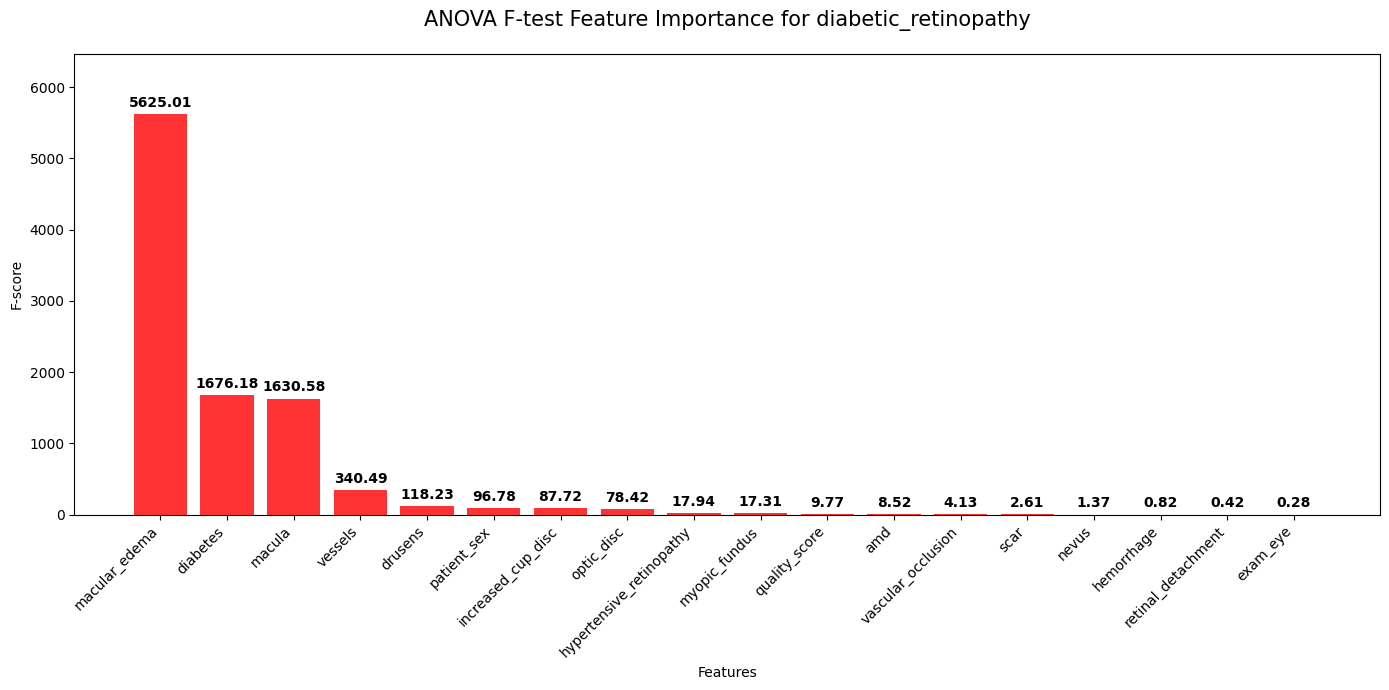

In [ ]:

# 1. Prepare base data2
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
target = 'diabetic_retinopathy'

# 2. Separate Features and Target
y = data2_clean[target]
# Dropping target, age, and ID
X = data2_clean.drop(columns=[target, 'patient_age', 'patient_id'], errors='ignore')

# 3. Compute ANOVA F-score
# f_classif returns (F-statistics, p-values). We take the F-statistics.
f_scores, _ = f_classif(X, y)

# 4. Convert to Series and Sort
f_series = pd.Series(f_scores, index=X.columns).sort_values(ascending=False)

# 5. Initialize the plot
fig, ax = plt.subplots(figsize=(14, 7))

# 6. Create the bar chart
# We use ax.bar instead of series.plot to easily grab the containers for labels
bars = ax.bar(f_series.index, f_series.values, color="red", alpha=0.8)

# 7. Add numbers above the bars (Enhanced Visualization)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10, fontweight='bold')

# 8. Customizing the plot
ax.set_title(f"ANOVA F-test Feature Importance for {target}", fontsize=15, pad=20)
ax.set_ylabel("F-score")
ax.set_xlabel("Features")

# Rotate x-axis labels to prevent overlapping
plt.xticks(rotation=45, ha='right')

# Adjust y-limit to give room for the labels at the top
ax.set_ylim(0, f_series.max() * 1.15)

plt.tight_layout()
plt.show()

Features used:
['patient_sex', 'exam_eye', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'quality_score']

ReliefF Feature Importance:
macula                      0.373046
diabetes                    0.178302
drusens                     0.126035
patient_sex                 0.066942
exam_eye                    0.063327
quality_score               0.052628
optic_disc                  0.026600
increased_cup_disc          0.024818
macular_edema               0.024456
vessels                     0.013849
myopic_fundus               0.012908
amd                         0.011644
scar                        0.010753
hypertensive_retinopathy    0.005263
vascular_occlusion          0.003849
nevus                       0.002585
hemorrhage                  0.001072
retinal_detachment          0.000038
dtype: float64


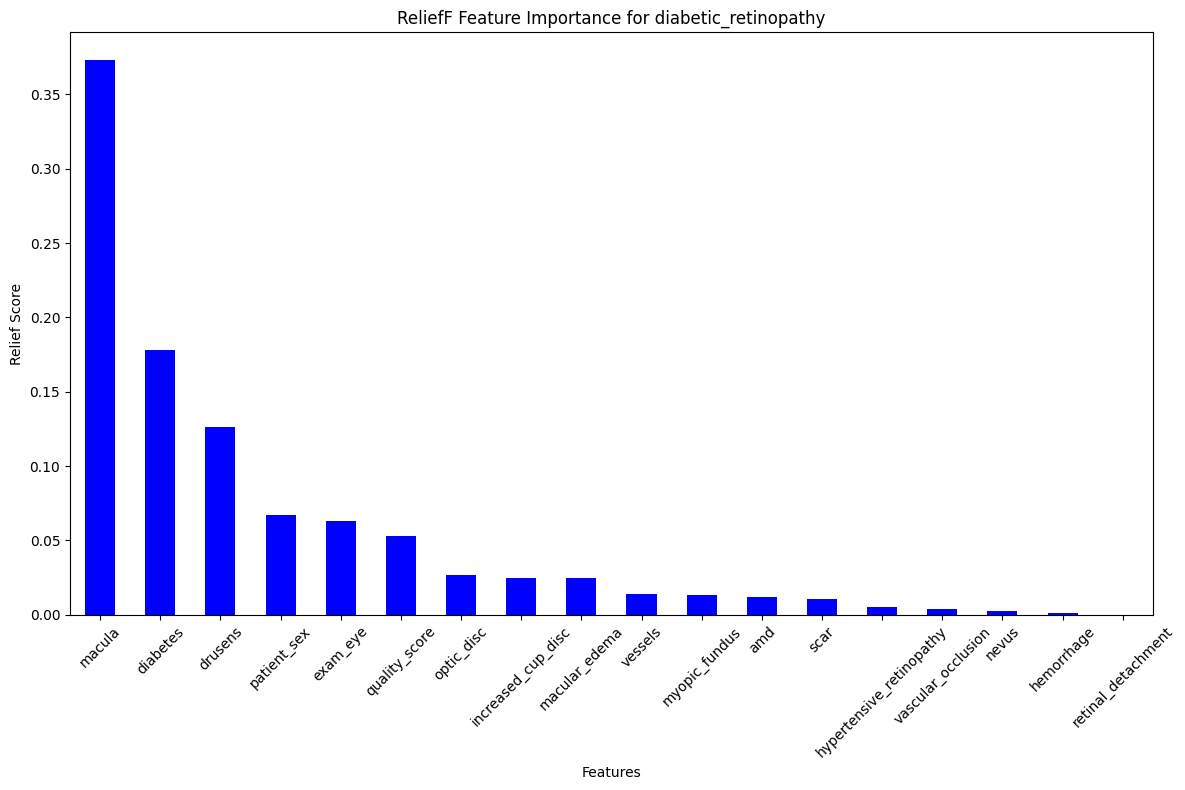

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from skrebate import ReliefF

# =========================
# 1) Prepare numeric data2
# =========================
data2_clean = data2.select_dtypes(include=["int64", "float64"]).copy()

# Target
target = "diabetic_retinopathy"
y_temp = data2_clean[target].to_numpy()

# Features
X_temp = data2_clean.drop(columns=[target], errors="ignore").copy()

# Optional: drop patient_age if you don't want to use it
X_temp = X_temp.drop(columns=["patient_age"], errors="ignore")

print("Features used:")
print(X_temp.columns.tolist())

# =========================
# 2) Remove constant features
# =========================
vt = VarianceThreshold(threshold=0.0)
X_var = vt.fit_transform(X_temp)
kept_cols = X_temp.columns[vt.get_support()]

# =========================
# 3) Scale features for ReliefF
# =========================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_var)

# =========================
# 4) Apply ReliefF
# =========================
relief = ReliefF(
    n_neighbors=20,
    n_features_to_select=X_scaled.shape[1]
)

relief.fit(X_scaled, y_temp)

# =========================
# 5) Collect feature importance
# =========================
relief_scores = pd.Series(relief.feature_importances_, index=kept_cols)
relief_scores = relief_scores.sort_values(ascending=False)

print("\nReliefF Feature Importance:")
print(relief_scores)

# =========================
# 6) Plot
# =========================
plt.figure(figsize=(12, 8))
relief_scores.plot(kind="bar", color="blue")
plt.title("ReliefF Feature Importance for diabetic_retinopathy")
plt.ylabel("Relief Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Forward Selection**

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# =========================
# 1. Target & Features
# =========================
target = 'diabetic_retinopathy'

y = data2_clean[target]

X = data2_clean.drop(columns=['diabetic_retinopathy'], errors='ignore')

# =========================
# 2. Model
# =========================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# =========================
# 3. Forward Selection
# =========================
remaining_features = list(X.columns)
selected_features = []
selected_scores = []

n_features_to_select = 10

for step in range(n_features_to_select):
    best_feature = None
    best_score = -1
    
    for feature in remaining_features:
        current_features = selected_features + [feature]
        
        score = cross_val_score(
            model,
            X[current_features],
            y,
            cv=3,
            scoring='f1_weighted',
            n_jobs=-1
        ).mean()
        
        if score > best_score:
            best_score = score
            best_feature = feature
    
    selected_features.append(best_feature)
    selected_scores.append(best_score)
    remaining_features.remove(best_feature)
    
    print(f"Step {step+1}: Added '{best_feature}' --> Score = {best_score:.4f}")

# =========================
# 4. Final Output
# =========================
print("\nFinal Selected Features:")
print(selected_features)+

Step 1: Added 'macular_edema' --> Score = 0.9453
Step 2: Added 'amd' --> Score = 0.9454
Step 3: Added 'drusens' --> Score = 0.9454
Step 4: Added 'optic_disc' --> Score = 0.9454
Step 5: Added 'scar' --> Score = 0.9457
Step 6: Added 'nevus' --> Score = 0.9457
Step 7: Added 'hemorrhage' --> Score = 0.9457
Step 8: Added 'macula' --> Score = 0.9457
Step 9: Added 'myopic_fundus' --> Score = 0.9559
Step 10: Added 'vascular_occlusion' --> Score = 0.9595

Final Selected Features:
['macular_edema', 'amd', 'drusens', 'optic_disc', 'scar', 'nevus', 'hemorrhage', 'macula', 'myopic_fundus', 'vascular_occlusion']


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# =========================
# 1. Target & Features
# =========================
target = 'diabetic_retinopathy'

y = data2_clean[target]

X = data2_clean.drop(columns=[
    'diabetic_retinopathy',
    'DR_ICDR',
    'DR_SDRG',
    'patient_id'
], errors='ignore')

# =========================
# 2. Model
# =========================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# =========================
# 3. Backward Selection
# =========================
current_features = list(X.columns)
selected_scores = []

n_features_to_select = 10

while len(current_features) > n_features_to_select:
    
    best_score = -1
    feature_to_remove = None
    
    for feature in current_features:
        temp_features = [f for f in current_features if f != feature]
        
        score = cross_val_score(
            model,
            X[temp_features],
            y,
            cv=3,
            scoring='f1_weighted',
            n_jobs=-1
        ).mean()
        
        if score > best_score:
            best_score = score
            feature_to_remove = feature
    
    current_features.remove(feature_to_remove)
    selected_scores.append(best_score)
    
    print(f"Removed '{feature_to_remove}' --> Score = {best_score:.4f}")

# =========================
# 4. Final Output
# =========================
print("\nFinal Selected Features:")
print(current_features)

Removed 'exam_eye' --> Score = 0.9617
Removed 'hypertensive_retinopathy' --> Score = 0.9618
Removed 'optic_disc' --> Score = 0.9618
Removed 'vessels' --> Score = 0.9616
Removed 'hemorrhage' --> Score = 0.9615
Removed 'retinal_detachment' --> Score = 0.9609
Removed 'nevus' --> Score = 0.9593
Removed 'quality_score' --> Score = 0.9572
Removed 'increased_cup_disc' --> Score = 0.9555

Final Selected Features:
['patient_age', 'patient_sex', 'diabetes', 'macula', 'macular_edema', 'scar', 'amd', 'vascular_occlusion', 'drusens', 'myopic_fundus']


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Target
target = 'diabetic_retinopathy'

# y
y_temp = data2_clean[target]

# X: drop target + leakage columns + ID
X_temp = data2_clean.drop(columns=['diabetic_retinopathy'], errors='ignore')

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# RFE
rfe = RFE(
    estimator=model,
    n_features_to_select=10,
    step=1
)

rfe.fit(X_temp, y_temp)

# Selected features
selected_features = X_temp.columns[rfe.support_]

# Print final list
print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'scar', 'drusens', 'myopic_fundus']


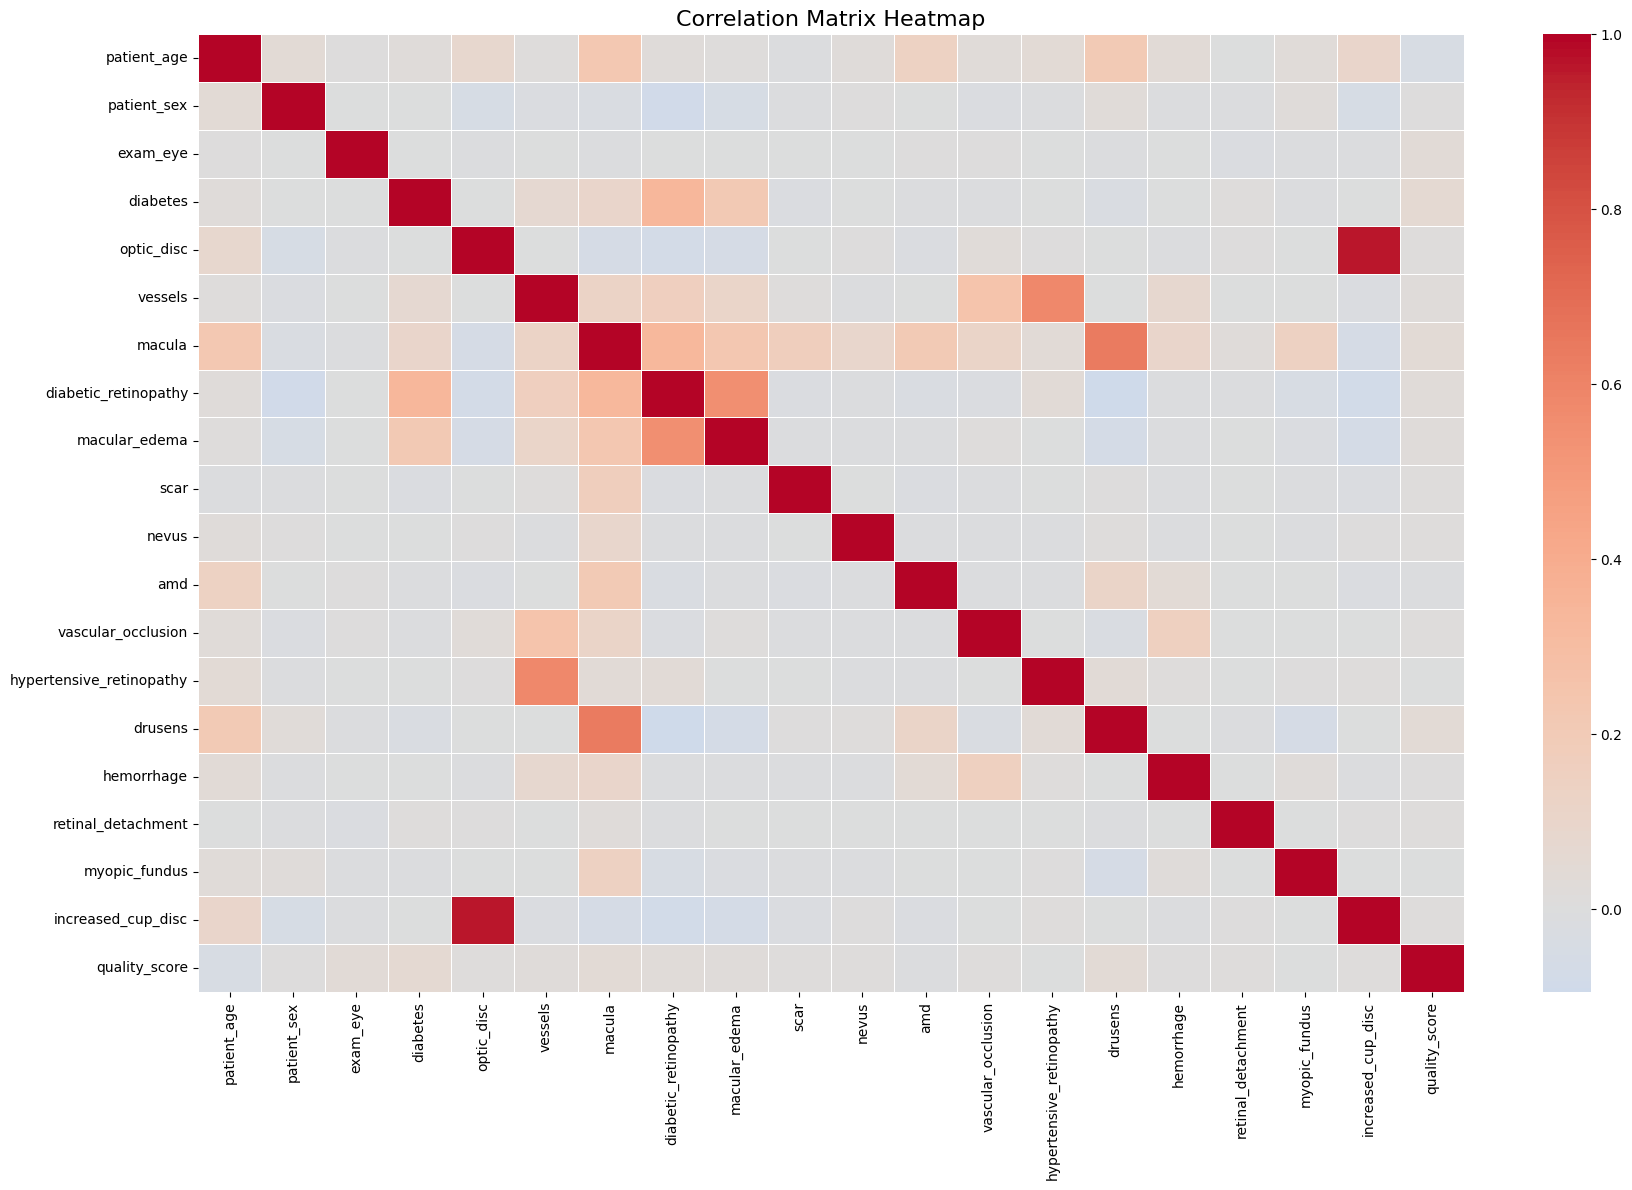

In [ ]:
# 1. Select numeric features only
data2_clean = data2.select_dtypes(include=['int64', 'float64']).copy()

# 2. Remove ID columns (VERY IMPORTANT)
data2_clean = data2_clean.drop(columns=['patient_id'], errors='ignore')

# 3. Compute correlation matrix
corr_matrix = data2_clean.corr()

# 4. Plot heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=False,          # keep False (too many features)
    cbar=True
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Features used:
['patient_sex', 'exam_eye', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'quality_score']
Accuracy: 0.8958893584325778

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.94      2432
           1       0.38      0.92      0.54       171

    accuracy                           0.90      2603
   macro avg       0.69      0.91      0.74      2603
weighted avg       0.95      0.90      0.91      2603


Feature Importance:
macula                      0.361653
diabetes                    0.265715
macular_edema               0.167852
drusens                     0.101002
vessels                     0.033820
patient_sex                 0.022847
increased_cup_disc          0.015169
optic_disc                  0.010336
myopic_fundus     

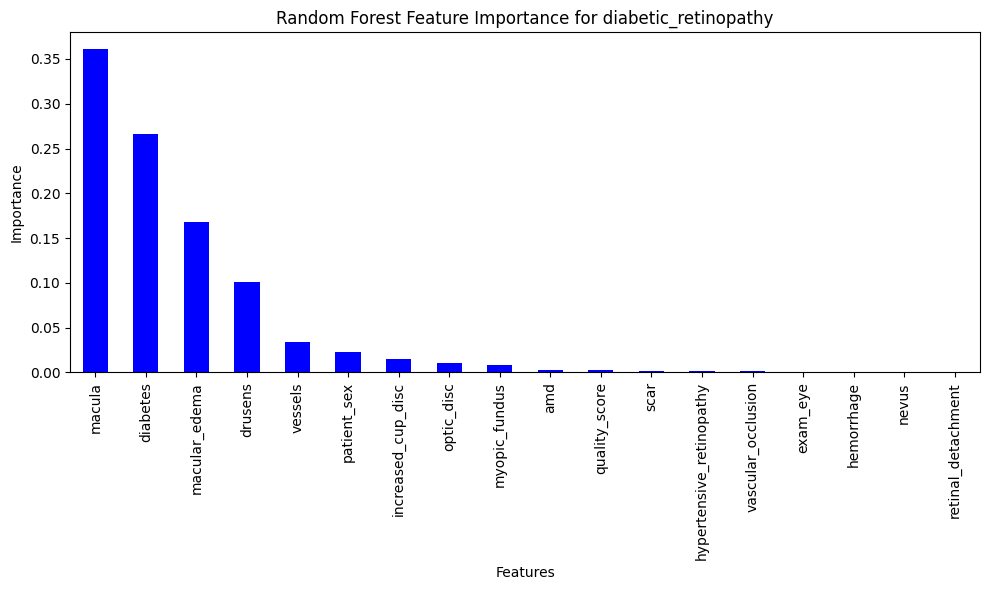

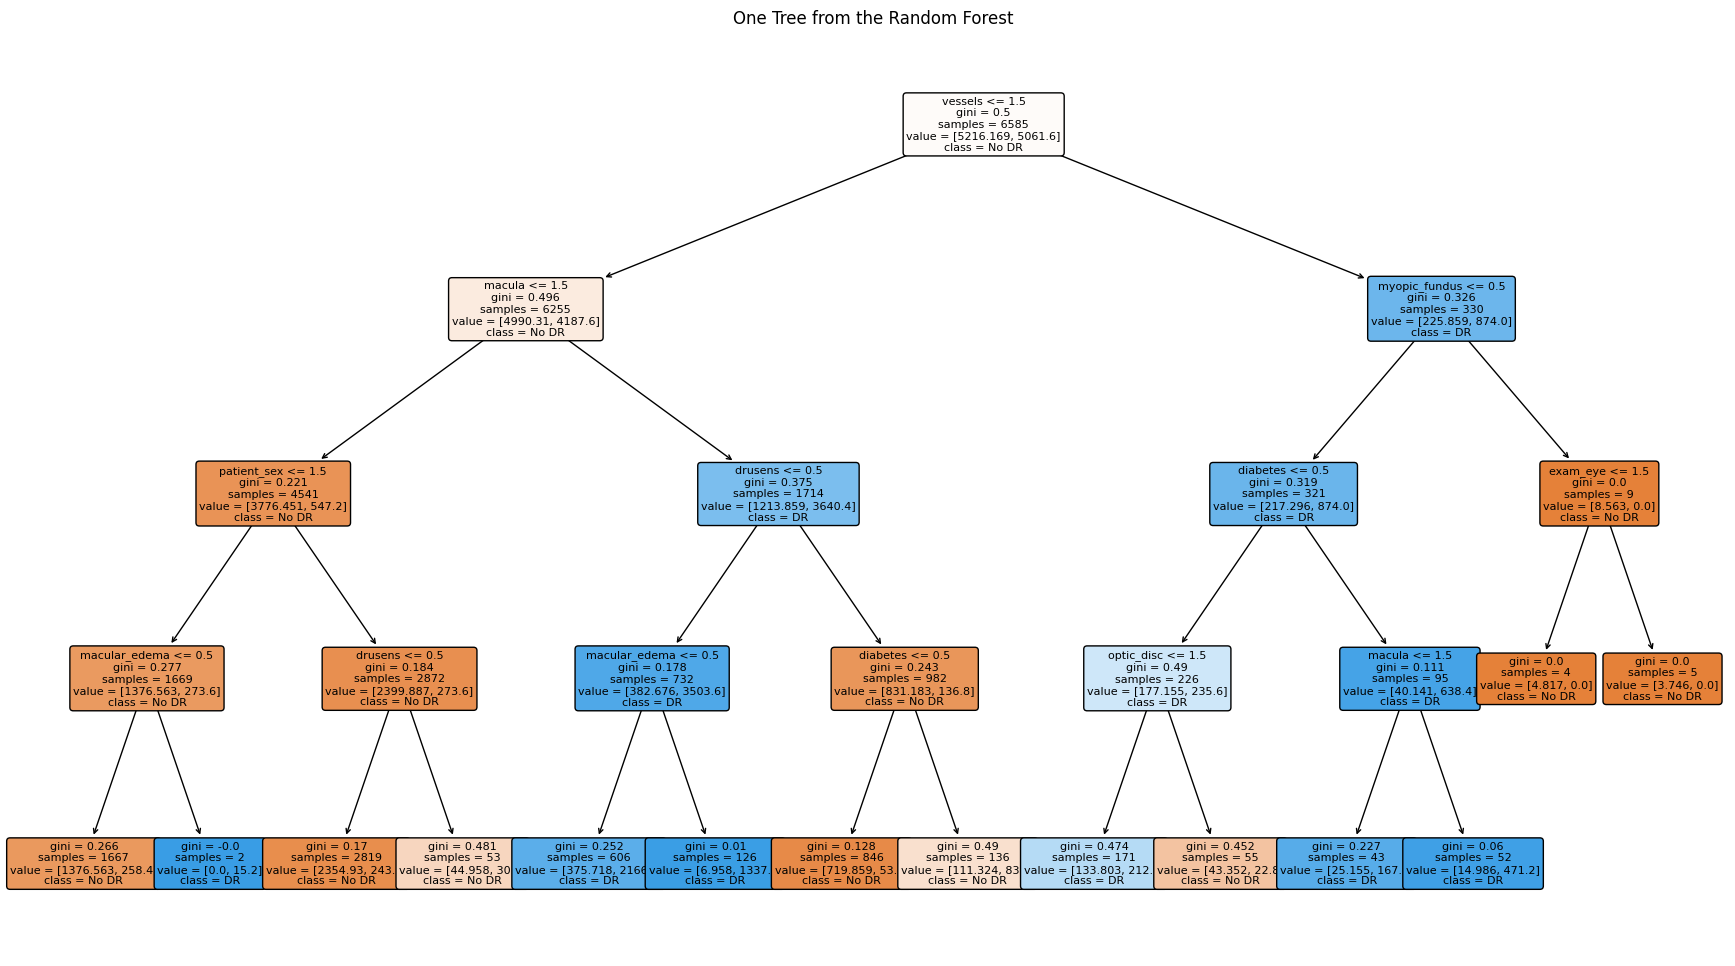

In [ ]:
data2_clean = data2.select_dtypes(include=['int64', 'float64']).copy()

# Target
y = data2_clean['diabetic_retinopathy']

# Features
X = data2_clean.drop(columns=['diabetic_retinopathy'], errors='ignore')

# Optional: drop patient_age if you don't want to use it
X = X.drop(columns=['patient_age'], errors='ignore')

print("Features used:")
print(X.columns.tolist())

# =========================
# 2) Train / test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3) Train Random Forest
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,   # keep trees readable
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

# =========================
# 4) Evaluate
# =========================
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# 5) Feature importance
# =========================
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar',color='blue')
plt.title("Random Forest Feature Importance for diabetic_retinopathy")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

# =========================
# 6) Visualize ONE tree from the forest
# =========================
plt.figure(figsize=(22, 12))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=['No DR', 'DR'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("One Tree from the Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import f1_score
print("F1-score:", f1_score(y_test, y_pred))

F1-score: 0.5367521367521367


In [ ]:
print(data2.info())
print(data2.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13015 entries, 0 to 13014
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   image_id                  13015 non-null  object 
 1   patient_id                13015 non-null  int64  
 2   camera                    13015 non-null  object 
 3   patient_age               8669 non-null   float64
 4   comorbidities             6396 non-null   object 
 5   diabetes_time_y           1545 non-null   object 
 6   insuline                  1381 non-null   object 
 7   patient_sex               13015 non-null  int64  
 8   exam_eye                  13015 non-null  int64  
 9   diabetes                  13015 non-null  object 
 10  nationality               13015 non-null  object 
 11  optic_disc                13015 non-null  int64  
 12  vessels                   13015 non-null  int64  
 13  macula                    13015 non-null  int64  
 14  DR_SDR

## **Model 1**

In [34]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is ready.")
    except RuntimeError as e:
        print(e)

TensorFlow version: 2.15.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready.


2026-04-20 20:12:48.697706: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 20:12:48.881064: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 20:12:48.881137: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [35]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
# =========================================================
# 1) LOAD DATA
# =========================================================
train_data = data2.copy()
val_data  = pd.read_csv("../../Data/dataset_split/val/val.csv")
test_data = pd.read_csv("../../Data/dataset_split/test/test.csv")

# If you want to keep it explicit:
# train_data2 = pd.read_csv("../../data/dataset_split/train/train.csv")

IMAGE_DIR = "path_to_images"   # <-- change this
TARGET = "diabetic_retinopathy"

tabular_features = [
    "patient_age",
    "patient_sex",
    "diabetes",
    "optic_disc",
    "vessels",
    "macula"
]


In [37]:
# =========================================================
# 2) BASIC CLEANING
# =========================================================
def clean_dataframe(df, tabular_features, target):
    df = df.copy()

    for col in tabular_features + [target, "exam_eye"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

train_data2 = clean_dataframe(train_data, tabular_features, TARGET)
val_data2   = clean_dataframe(val_data, tabular_features, TARGET)
test_data2  = clean_dataframe(test_data, tabular_features, TARGET)

print("\nAfter cleaning:")
print("train_data2:", train_data2.shape)
print("val_data2  :", val_data2.shape)
print("test_data2 :", test_data2.shape)


After cleaning:
train_data2: (13015, 23)
val_data2  : (1632, 34)
test_data2 : (1619, 34)


In [38]:
# =========================================================
# 3) IMAGE PATHS
# =========================================================
# Make these EXACTLY match your real folders
TRAIN_IMAGE_DIR = "../../Data/dataset_split/train/images"
VAL_IMAGE_DIR   = "../../Data/dataset_split/val/images"
TEST_IMAGE_DIR  = "../../Data/dataset_split/test/images"

print("\nImage dir existence:")
print("TRAIN_IMAGE_DIR exists:", os.path.exists(TRAIN_IMAGE_DIR), TRAIN_IMAGE_DIR)
print("VAL_IMAGE_DIR exists  :", os.path.exists(VAL_IMAGE_DIR), VAL_IMAGE_DIR)
print("TEST_IMAGE_DIR exists :", os.path.exists(TEST_IMAGE_DIR), TEST_IMAGE_DIR)


def find_image_path(image_id, image_dir):
    image_id = str(image_id).strip()

    # try exact id first
    candidates = [
        image_id,
        image_id.lower(),
        image_id.upper()
    ]

    for candidate in candidates:
        for ext in [".png", ".jpg", ".jpeg", ".JPG", ".JPEG", ".PNG"]:
            path = os.path.join(image_dir, candidate + ext)
            if os.path.exists(path):
                return path

    return None


def attach_image_paths(df, image_dir, name="df"):
    df = df.copy()

    print(f"\n--- Attaching image paths for {name} ---")
    print("Input shape:", df.shape)
    print("Image dir exists:", os.path.exists(image_dir), image_dir)

    if "image_id" not in df.columns:
        raise ValueError(f"{name} does not contain 'image_id' column")

    print("Sample image_ids:", df["image_id"].astype(str).head(10).tolist())

    df["image_path"] = df["image_id"].astype(str).apply(lambda x: find_image_path(x, image_dir))

    found = df["image_path"].notna().sum()
    missing = df["image_path"].isna().sum()

    print("Images found:", found)
    print("Images missing:", missing)

    if found == 0:
        print("Warning: No images were matched. Check image_dir, file names, and extensions.")

    print("Sample resolved paths:", df["image_path"].dropna().head(5).tolist())

    df = df.dropna(subset=["image_path"]).reset_index(drop=True)

    print("Output shape after dropping missing image_path:", df.shape)
    return df


train_data2 = attach_image_paths(train_data2, TRAIN_IMAGE_DIR, "train")
val_data2   = attach_image_paths(val_data2, VAL_IMAGE_DIR, "val")
test_data2  = attach_image_paths(test_data2, TEST_IMAGE_DIR, "test")


Image dir existence:
TRAIN_IMAGE_DIR exists: True ../../Data/dataset_split/train/images
VAL_IMAGE_DIR exists  : True ../../Data/dataset_split/val/images
TEST_IMAGE_DIR exists : True ../../Data/dataset_split/test/images

--- Attaching image paths for train ---
Input shape: (13015, 23)
Image dir exists: True ../../Data/dataset_split/train/images
Sample image_ids: ['img00001', 'img00002', 'img00003', 'img00004', 'img00005', 'img00006', 'img00007', 'img00008', 'img00009', 'img00010']
Images found: 13015
Images missing: 0
Sample resolved paths: ['../../Data/dataset_split/train/images/img00001.jpg', '../../Data/dataset_split/train/images/img00002.jpg', '../../Data/dataset_split/train/images/img00003.jpg', '../../Data/dataset_split/train/images/img00004.jpg', '../../Data/dataset_split/train/images/img00005.jpg']
Output shape after dropping missing image_path: (13015, 24)

--- Attaching image paths for val ---
Input shape: (1632, 34)
Image dir exists: True ../../Data/dataset_split/val/images


In [43]:
# =========================================================
# 4) IMAGE-LEVEL -> PATIENT-LEVEL
# =========================================================
def build_patient_level_df(df, target, name="df"):
    df = df.copy()

    print(f"\n--- Building patient-level df for {name} ---")
    print("Input shape:", df.shape)

    if df.empty:
        print("Warning: input dataframe is empty")
        return pd.DataFrame(columns=[
            "patient_id", "patient_age", "patient_sex", "diabetes",
            "optic_disc", "vessels", "macula", target,
            "left_image_path", "right_image_path"
        ])

    # -----------------------------------------
    # normalize raw eye labels to strings
    # -----------------------------------------
    df["exam_eye"] = df["exam_eye"].astype(str).str.strip().str.lower()

    raw_unique = sorted(df["exam_eye"].dropna().unique().tolist())
    print("exam_eye raw unique:", raw_unique)

    # -----------------------------------------
    # detect coding scheme automatically
    # scheme A: 0=left, 1=right
    # scheme B: 1=left, 2=right
    # -----------------------------------------
    raw_set = set(raw_unique)

    if raw_set.issubset({"0", "1"}):
        eye_map = {
            "0": "left",
            "1": "right",
            "l": "left",
            "r": "right",
            "left": "left",
            "right": "right"
        }
        print("Detected eye coding: 0=left, 1=right")

    elif raw_set.issubset({"1", "2"}):
        eye_map = {
            "1": "left",
            "2": "right",
            "l": "left",
            "r": "right",
            "left": "left",
            "right": "right"
        }
        print("Detected eye coding: 1=left, 2=right")

    else:
        raise ValueError(
            f"{name}: Unsupported or mixed exam_eye values found: {raw_unique}"
        )

    df["exam_eye_norm"] = df["exam_eye"].map(eye_map)

    print("exam_eye normalized counts:\n", df["exam_eye_norm"].value_counts(dropna=False))

    # safety check
    if df["exam_eye_norm"].isna().any():
        bad_vals = df.loc[df["exam_eye_norm"].isna(), "exam_eye"].unique()
        raise ValueError(f"{name}: Unmapped exam_eye values found: {bad_vals}")

    # -----------------------------------------
    # split left and right
    # -----------------------------------------
    left_df = df[df["exam_eye_norm"] == "left"][["patient_id", "image_path"]].copy()
    right_df = df[df["exam_eye_norm"] == "right"][["patient_id", "image_path"]].copy()

    left_df = left_df.rename(columns={"image_path": "left_image_path"})
    right_df = right_df.rename(columns={"image_path": "right_image_path"})

    print("left_df shape :", left_df.shape)
    print("right_df shape:", right_df.shape)

    # -----------------------------------------
    # aggregate patient-level tabular data
    # -----------------------------------------
    agg_dict = {
        "patient_age": "first",
        "patient_sex": "first",
        "diabetes": "first",
        "optic_disc": "max",
        "vessels": "max",
        "macula": "max",
        target: "max"
    }

    patient_tab = df.groupby("patient_id").agg(agg_dict).reset_index()
    print("patient_tab shape:", patient_tab.shape)

    # -----------------------------------------
    # merge left/right eyes
    # -----------------------------------------
    patient_df = patient_tab.merge(left_df, on="patient_id", how="left")
    patient_df = patient_df.merge(right_df, on="patient_id", how="left")

    print("Missing left image :", patient_df["left_image_path"].isna().sum())
    print("Missing right image:", patient_df["right_image_path"].isna().sum())

    # keep only complete pairs
    patient_df = patient_df.dropna(
        subset=["left_image_path", "right_image_path", target]
    ).reset_index(drop=True)

    print("Final patient_df shape:", patient_df.shape)
    return patient_df


train_df = build_patient_level_df(train_data2, TARGET, "train")
val_df   = build_patient_level_df(val_data2, TARGET, "val")
test_df  = build_patient_level_df(test_data2, TARGET, "test")

print("\nFinal patient-level shapes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)


--- Building patient-level df for train ---
Input shape: (13015, 24)
exam_eye raw unique: ['0', '1']
Detected eye coding: 0=left, 1=right
exam_eye normalized counts:
 exam_eye_norm
left     6530
right    6485
Name: count, dtype: int64
left_df shape : (6530, 2)
right_df shape: (6485, 2)
patient_tab shape: (6819, 8)
Missing left image : 384
Missing right image: 424
Final patient_df shape: (6119, 10)

--- Building patient-level df for val ---
Input shape: (1632, 35)
exam_eye raw unique: ['1', '2']
Detected eye coding: 1=left, 2=right
exam_eye normalized counts:
 exam_eye_norm
left     817
right    815
Name: count, dtype: int64
left_df shape : (817, 2)
right_df shape: (815, 2)
patient_tab shape: (852, 8)
Missing left image : 50
Missing right image: 52
Final patient_df shape: (767, 10)

--- Building patient-level df for test ---
Input shape: (1619, 35)
exam_eye raw unique: ['1', '2']
Detected eye coding: 1=left, 2=right
exam_eye normalized counts:
 exam_eye_norm
right    811
left     808
N

In [44]:
# =========================================================
# 5) TABULAR PREPROCESSING
# =========================================================
if train_df.empty:
    raise ValueError("train_df is empty after patient-level construction. Check image matching and exam_eye values.")

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_tab = imputer.fit_transform(train_df[tabular_features])
X_val_tab   = imputer.transform(val_df[tabular_features])
X_test_tab  = imputer.transform(test_df[tabular_features])

X_train_tab = scaler.fit_transform(X_train_tab)
X_val_tab   = scaler.transform(X_val_tab)
X_test_tab  = scaler.transform(X_test_tab)

print("\nTabular arrays:")
print("X_train_tab:", X_train_tab.shape)
print("X_val_tab  :", X_val_tab.shape)
print("X_test_tab :", X_test_tab.shape)


Tabular arrays:
X_train_tab: (6119, 6)
X_val_tab  : (767, 6)
X_test_tab : (754, 6)


In [45]:
# =========================================================
# 5.5) LABELS
# =========================================================
y_train = train_df[TARGET].values.astype("float32")
y_val   = val_df[TARGET].values.astype("float32")
y_test  = test_df[TARGET].values.astype("float32")

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

y_train shape: (6119,)
y_val shape: (767,)
y_test shape: (754,)


In [46]:


# =========================================================
# 6) IMAGE LOADER
# =========================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

def load_image(path):
    img = tf.io.read_file(path)

    # safer decoder for mixed jpg/png files
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])

    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_dataset(left_paths, right_paths, tabular_data, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((left_paths, right_paths, tabular_data, labels))

    def _map_fn(lp, rp, tab, label):
        left_img = load_image(lp)
        right_img = load_image(rp)

        return {
            "left_image_input": left_img,
            "right_image_input": right_img,
            "tabular_input": tf.cast(tab, tf.float32)
        }, tf.cast(label, tf.float32)

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(
    train_df["left_image_path"].values,
    train_df["right_image_path"].values,
    X_train_tab,
    y_train,
    training=True
)

val_ds = make_dataset(
    val_df["left_image_path"].values,
    val_df["right_image_path"].values,
    X_val_tab,
    y_val,
    training=False
)

test_ds = make_dataset(
    test_df["left_image_path"].values,
    test_df["right_image_path"].values,
    X_test_tab,
    y_test,
    training=False
)

2026-04-20 20:18:42.591038: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 20:18:42.591601: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 20:18:42.591881: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 20:18:43.688124: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-20 20:18:43.688246: I external/local_xla/xla/stream_executor

In [ ]:
from tensorflow.keras import layers, models
tf.keras.backend.clear_session()
# =========================================================
# IMAGE BACKBONE (shared)
# =========================================================
def create_image_branch():
    base = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    base.trainable = False  # freeze for now

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation="relu")(x)

    return models.Model(inputs=base.input, outputs=x)


# =========================================================
# BUILD MULTIMODAL MODEL
# =========================================================
def build_model(tabular_dim):
    # inputs
    left_input = layers.Input(shape=(224, 224, 3), name="left_image_input")
    right_input = layers.Input(shape=(224, 224, 3), name="right_image_input")
    tab_input = layers.Input(shape=(tabular_dim,), name="tabular_input")

    # image branch (shared weights)
    image_branch = create_image_branch()

    left_feat = image_branch(left_input)
    right_feat = image_branch(right_input)

    # combine images
    img_features = layers.Concatenate()([left_feat, right_feat])

    # tabular branch
    tab = layers.Dense(64, activation="relu")(tab_input)
    tab = layers.Dense(32, activation="relu")(tab)

    # combine all
    combined = layers.Concatenate()([img_features, tab])

    x = layers.Dense(128, activation="relu")(combined)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(2, activation="sigmoid")(x)

    model = models.Model(
        inputs={
            "left_image_input": left_input,
            "right_image_input": right_input,
            "tabular_input": tab_input
        },
        outputs=output
    )

    return model


# =========================================================
# CREATE MODEL
# =========================================================
model = build_model(tabular_dim=X_train_tab.shape[1])

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 left_image_input (InputLay  [(None, 224, 224, 3)]        0         []                            
 er)                                                                                              
                                                                                                  
 right_image_input (InputLa  [(None, 224, 224, 3)]        0         []                            
 yer)                                                                                             
                                                                                                  
 tabular_input (InputLayer)  [(None, 6)]                  0         []                            
                                                                                            

In [48]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled


In [ ]:
import tensorflow as tf
import numpy as np
import json
from sklearn.utils.class_weight import compute_class_weight

# Optional but useful if rerunning cells in notebook
tf.keras.backend.clear_session()

# =========================
# COMPILE
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc")
]
)

# =========================
# CLASS WEIGHTS
# =========================
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight = {int(k): v for k, v in zip(classes, weights)}

print("Class weights:", class_weight)

# =========================
# CALLBACKS
# =========================
my_callbacks = [
    # save best model based on validation AUC
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_fundus_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    # save latest model every epoch for resume
    tf.keras.callbacks.ModelCheckpoint(
        filepath="last_fundus_model(`).keras",
        save_best_only=False,
        verbose=1
    ),

]

# =========================
# TRAIN FIRST STAGE
# =========================
history_part1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7,   # first stage target
    callbacks=my_callbacks,
    class_weight=class_weight,
    verbose=1
)

# =========================
# SAVE LAST COMPLETED EPOCH
# =========================
# len(history.history["loss"]) = number of epochs actually completed in this run
completed_epochs_stage1 = len(history_part1.history["loss"])

with open("resume_info.json", "w") as f:
    json.dump({"completed_epochs": completed_epochs_stage1}, f)

print(f"Stage 1 finished. Completed epochs = {completed_epochs_stage1}")

# Optional extra save
model.save("stage1(DR_ICDR).keras")
print("Stage 1 model saved successfully!")

Class weights: {0: 0.21557160472080325, 1: 20.39666666666667, 2: 7.198823529411765, 3: 33.075675675675676, 4: 6.993142857142857}
Epoch 1/7


2026-04-20 20:26:51.830775: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-20 20:26:52.223635: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-20 20:26:52.387684: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-20 20:26:57.159134: W external/local_tsl/tsl/framework/bfc_allocator.cc:366] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
2026-04-20 20:26:57.398181: W externa

765/765 [==============================] - ETA: 0s - loss: 1.6816 - acc: 0.2543 - top2_acc: 0.5282WARNING:tensorflow:Can save best model only with val_auc available, skipping.

Epoch 1: saving model to last_fundus_model(`).keras
765/765 [==============================] - 118s 124ms/step - loss: 1.6816 - acc: 0.2543 - top2_acc: 0.5282 - val_loss: 1.6107 - val_acc: 0.0691 - val_top2_acc: 0.0808
Epoch 2/7


2026-04-20 20:28:44.600110: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 872 of 1000
2026-04-20 20:28:46.633488: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


765/765 [==============================] - ETA: 0s - loss: 1.5461 - acc: 0.4797 - top2_acc: 0.6612WARNING:tensorflow:Can save best model only with val_auc available, skipping.

Epoch 2: saving model to last_fundus_model(`).keras
765/765 [==============================] - 109s 126ms/step - loss: 1.5461 - acc: 0.4797 - top2_acc: 0.6612 - val_loss: 1.1943 - val_acc: 0.6649 - val_top2_acc: 0.7288
Epoch 3/7


2026-04-20 20:30:33.548201: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 934 of 1000
2026-04-20 20:30:34.368125: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


765/765 [==============================] - ETA: 0s - loss: 1.4487 - acc: 0.6638 - top2_acc: 0.7727WARNING:tensorflow:Can save best model only with val_auc available, skipping.

Epoch 3: saving model to last_fundus_model(`).keras
765/765 [==============================] - 105s 122ms/step - loss: 1.4487 - acc: 0.6638 - top2_acc: 0.7727 - val_loss: 1.0108 - val_acc: 0.7223 - val_top2_acc: 0.7575
Epoch 4/7


2026-04-20 20:32:18.110684: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 931 of 1000
2026-04-20 20:32:18.883586: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


425/765 [===============>..............] - ETA: 38s - loss: 1.5041 - acc: 0.6659 - top2_acc: 0.7165

In [ ]:
import tensorflow as tf
import numpy as np
import json
from sklearn.utils.class_weight import compute_class_weight

# Optional but useful if rerunning cells in notebook
tf.keras.backend.clear_session()

# =========================
# LOAD LAST MODEL
# =========================
model = tf.keras.models.load_model("last_fundus_model.keras")

# =========================
# READ LAST COMPLETED EPOCH
# =========================
with open("resume_info.json", "r") as f:
    resume_info = json.load(f)

start_epoch = resume_info["completed_epochs"]
print("Resuming from epoch:", start_epoch)

# =========================
# CLASS WEIGHTS AGAIN
# =========================
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight = {int(k): v for k, v in zip(classes, weights)}

print("Class weights:", class_weight)

# =========================
# CALLBACKS AGAIN
# =========================
my_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_fundus_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="last_fundus_model.keras",
        save_best_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=False,
        verbose=1
    )
]

# =========================
# CONTINUE TRAINING
# =========================
history_part2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=start_epoch,
    epochs=15,   # total final target
    callbacks=my_callbacks,
    class_weight=class_weight,
    verbose=1
)

# =========================
# SAVE FINAL MODEL
# =========================
model.save("final_fundus_model.keras")
print("Final model saved successfully!")

In [32]:


# =========================================================
# 9) EVALUATION
# =========================================================
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import numpy as np

# predict probabilities
pred_probs = model.predict(test_ds).ravel()

# convert to class labels
preds = (pred_probs >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, pred_probs))
print("F1-score:", f1_score(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

95/95 [==============================] - 12s 113ms/step
ROC-AUC: 0.8086189572401474
F1-score: 0.3684210526315789

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9445    0.9144    0.9292       689
         1.0     0.3218    0.4308    0.3684        65

    accuracy                         0.8727       754
   macro avg     0.6332    0.6726    0.6488       754
weighted avg     0.8908    0.8727    0.8809       754

Confusion Matrix:
[[630  59]
 [ 37  28]]


## **XAI GPU**

In [36]:
# =========================================================
# GPU CHECK
# =========================================================
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

# optional memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

# =========================================================
# IMAGE LOADER
# =========================================================
def load_image_for_xai(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img.numpy()

# =========================================================
# FAST GPU FORWARD PASS
# =========================================================
@tf.function
def gpu_forward(left_batch, right_batch, tab_batch):
    return model({
        "left_image_input": left_batch,
        "right_image_input": right_batch,
        "tabular_input": tab_batch
    }, training=False)

# =========================================================
# WRAPPERS
# =========================================================
def predict_batch_gpu(left_batch, right_batch, tab_batch, batch_size=32):
    left_batch = np.asarray(left_batch, dtype=np.float32)
    right_batch = np.asarray(right_batch, dtype=np.float32)
    tab_batch = np.asarray(tab_batch, dtype=np.float32)

    outputs = []
    n = len(left_batch)

    for i in range(0, n, batch_size):
        lb = tf.convert_to_tensor(left_batch[i:i+batch_size], dtype=tf.float32)
        rb = tf.convert_to_tensor(right_batch[i:i+batch_size], dtype=tf.float32)
        tb = tf.convert_to_tensor(tab_batch[i:i+batch_size], dtype=tf.float32)

        preds = gpu_forward(lb, rb, tb)
        outputs.append(preds.numpy().ravel())

    return np.concatenate(outputs, axis=0)


TensorFlow version: 2.15.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled


In [37]:
# =========================================================
# MAIN XAI FUNCTION
# =========================================================
def explain_multimodal_sample_gpu(
    model,
    test_df,
    X_test_tab,
    y_test,
    X_train_tab,
    tabular_features,
    sample_idx=0,
    lime_num_samples=300,
    shap_nsamples=100,
    shap_background_size=30,
    pred_batch_size=32
):
    row = test_df.iloc[sample_idx]

    left_img_path = row["left_image_path"]
    right_img_path = row["right_image_path"]

    sample_tab = X_test_tab[sample_idx].astype(np.float32)
    sample_label = y_test[sample_idx]

    left_img = load_image_for_xai(left_img_path)
    right_img = load_image_for_xai(right_img_path)

    # -------------------------
    # base prediction
    # -------------------------
    pred_prob = predict_batch_gpu(
        left_batch=np.expand_dims(left_img, axis=0),
        right_batch=np.expand_dims(right_img, axis=0),
        tab_batch=np.expand_dims(sample_tab, axis=0),
        batch_size=1
    )[0]

    print("Patient ID:", row["patient_id"])
    print("True label:", int(sample_label))
    print("Predicted DR probability:", float(pred_prob))
    print("Predicted class:", int(pred_prob >= 0.5))

    # =========================================================
    # LIME LEFT
    # =========================================================
    def predict_for_lime_left(images):
        n = images.shape[0]

        right_batch = np.repeat(
            np.expand_dims(right_img, axis=0), n, axis=0
        ).astype(np.float32)

        tab_batch = np.repeat(
            np.expand_dims(sample_tab, axis=0), n, axis=0
        ).astype(np.float32)

        preds = predict_batch_gpu(
            left_batch=images.astype(np.float32),
            right_batch=right_batch,
            tab_batch=tab_batch,
            batch_size=pred_batch_size
        )

        return np.vstack([1 - preds, preds]).T

    explainer_left = lime_image.LimeImageExplainer()
    explanation_left = explainer_left.explain_instance(
        image=left_img,
        classifier_fn=predict_for_lime_left,
        top_labels=2,
        hide_color=0,
        num_samples=lime_num_samples
    )

    temp_left, mask_left = explanation_left.get_image_and_mask(
        label=1,
        positive_only=True,
        num_features=8,
        hide_rest=False
    )

    # =========================================================
    # LIME RIGHT
    # =========================================================
    def predict_for_lime_right(images):
        n = images.shape[0]

        left_batch = np.repeat(
            np.expand_dims(left_img, axis=0), n, axis=0
        ).astype(np.float32)

        tab_batch = np.repeat(
            np.expand_dims(sample_tab, axis=0), n, axis=0
        ).astype(np.float32)

        preds = predict_batch_gpu(
            left_batch=left_batch,
            right_batch=images.astype(np.float32),
            tab_batch=tab_batch,
            batch_size=pred_batch_size
        )

        return np.vstack([1 - preds, preds]).T

    explainer_right = lime_image.LimeImageExplainer()
    explanation_right = explainer_right.explain_instance(
        image=right_img,
        classifier_fn=predict_for_lime_right,
        top_labels=2,
        hide_color=0,
        num_samples=lime_num_samples
    )

    temp_right, mask_right = explanation_right.get_image_and_mask(
        label=1,
        positive_only=True,
        num_features=8,
        hide_rest=False
    )

    # =========================================================
    # SHAP TABULAR
    # =========================================================
    def predict_for_shap_tab(tabular_array):
        tabular_array = np.asarray(tabular_array, dtype=np.float32)
        n = tabular_array.shape[0]

        left_batch = np.repeat(
            np.expand_dims(left_img, axis=0), n, axis=0
        ).astype(np.float32)

        right_batch = np.repeat(
            np.expand_dims(right_img, axis=0), n, axis=0
        ).astype(np.float32)

        preds = predict_batch_gpu(
            left_batch=left_batch,
            right_batch=right_batch,
            tab_batch=tabular_array,
            batch_size=pred_batch_size
        )

        return preds

    background_size = min(shap_background_size, len(X_train_tab))
    background_idx = np.random.choice(len(X_train_tab), background_size, replace=False)
    background_tab = X_train_tab[background_idx].astype(np.float32)

    explainer_shap = shap.KernelExplainer(
        model=predict_for_shap_tab,
        data=background_tab
    )

    sample_tab_2d = np.expand_dims(sample_tab, axis=0).astype(np.float32)
    shap_values = explainer_shap.shap_values(sample_tab_2d, nsamples=shap_nsamples)

    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[0]
    else:
        shap_values_to_plot = shap_values

    shap_vals_1d = shap_values_to_plot[0]

    # =========================================================
    # PLOT
    # =========================================================
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(mark_boundaries(temp_left, mask_left))
    axes[0].set_title("Left Eye - LIME")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(temp_right, mask_right))
    axes[1].set_title("Right Eye - LIME")
    axes[1].axis("off")

    sorted_idx = np.argsort(np.abs(shap_vals_1d))[::-1]
    top_k = min(len(tabular_features), 10)
    top_idx = sorted_idx[:top_k]

    axes[2].barh(
        [tabular_features[i] for i in top_idx][::-1],
        shap_vals_1d[top_idx][::-1]
    )
    axes[2].set_title("Tabular - SHAP")
    axes[2].set_xlabel("SHAP value")

    plt.tight_layout()
    plt.show()

    return {
        "patient_id": row["patient_id"],
        "true_label": int(sample_label),
        "pred_prob": float(pred_prob),
        "pred_class": int(pred_prob >= 0.5),
        "left_img_path": left_img_path,
        "right_img_path": right_img_path,
        "shap_values": shap_vals_1d
    }

Patient ID: 20
True label: 0
Predicted DR probability: 0.4617079794406891
Predicted class: 0


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

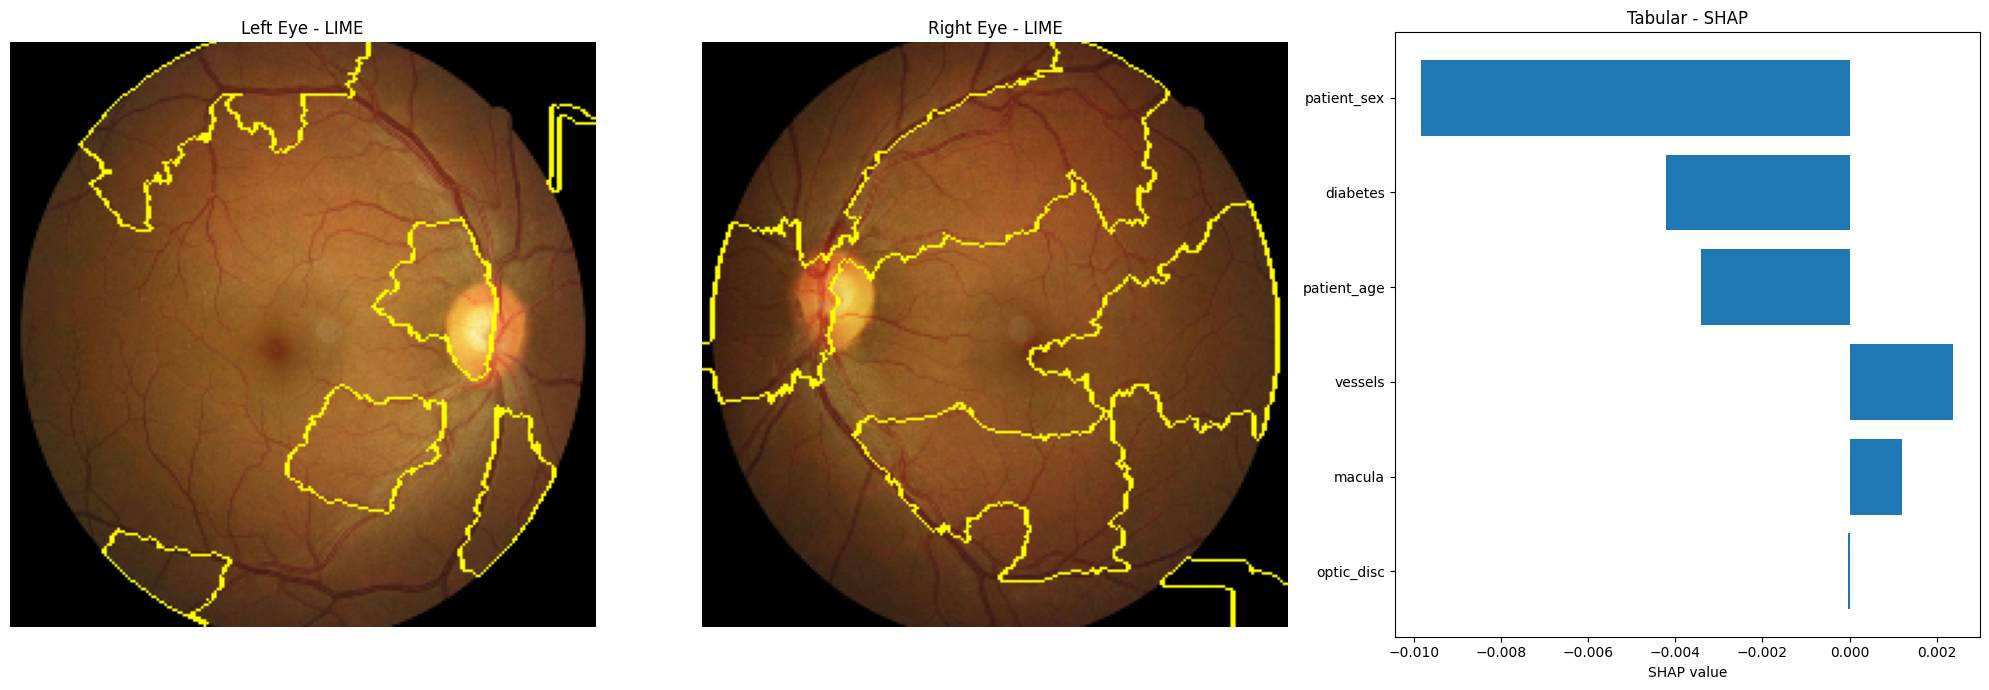

In [38]:
result = explain_multimodal_sample_gpu(
    model=model,
    test_df=test_df,
    X_test_tab=X_test_tab,
    y_test=y_test,
    X_train_tab=X_train_tab,
    tabular_features=tabular_features,
    sample_idx=0,
    lime_num_samples=300,
    shap_nsamples=100,
    shap_background_size=30,
    pred_batch_size=32
)